In [191]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [192]:
months=['Jan','Feb', 'Mar', 'Apr','May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
df=pd.read_csv("us_retail_sales.csv",
               names=['Year', *months],
               skiprows=1)

In [193]:
df=df.melt(id_vars=['Year'], var_name='Month', value_vars=months)

In [194]:
df.head()

,Year,Month,value
0,1992,Jan,146925.0
1,1993,Jan,157555.0
2,1994,Jan,167518.0
3,1995,Jan,182413.0
4,1996,Jan,189135.0


In [195]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 360 entries, 0 to 359
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Year    360 non-null    int64  
 1   Month   360 non-null    object 
 2   value   354 non-null    float64
dtypes: float64(1), int64(1), object(1)
memory usage: 8.6+ KB


The null values starting after June make sense because the prompt said it only went through June 2021.

## Mapping the month codes to an integer

In [196]:
df['Month']=df['Month'].map({m: i + 1 for i, m in enumerate(months)})
df.head()

,Year,Month,value
0,1992,1,146925.0
1,1993,1,157555.0
2,1994,1,167518.0
3,1995,1,182413.0
4,1996,1,189135.0


## Combine Year and Month into a Single Date Column

In [197]:
df['Date']=pd.to_datetime(df['Year'].map(str)+'-'+df['Month'].map(str))

In [198]:
df.head()

,Year,Month,value,Date
0,1992,1,146925.0,1992-01-01
1,1993,1,157555.0,1993-01-01
2,1994,1,167518.0,1994-01-01
3,1995,1,182413.0,1995-01-01
4,1996,1,189135.0,1996-01-01


In [199]:
df=df.sort_values('Date')
col='Date'
col_data=df.pop(col)
df.insert(0,col,col_data)
df.head()
df_new=df.drop(['Year','Month'], axis=1)
df_new.set_index('Date',inplace=True)
df_final=df_new.dropna()

In [200]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 354 entries, 1992-01-01 to 2021-06-01
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   value   354 non-null    float64
dtypes: float64(1)
memory usage: 5.5 KB


# Plot the data and make some observations about the graph

<Axes: xlabel='Date'>

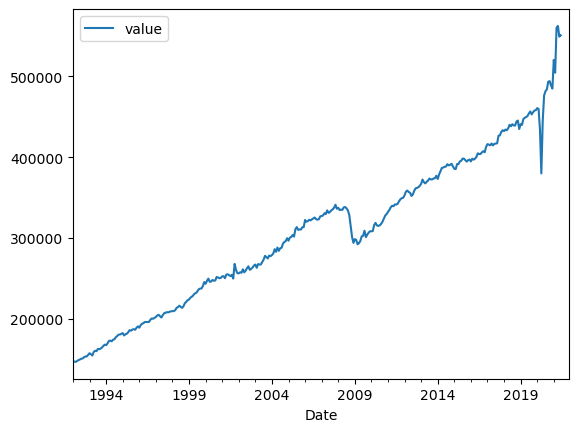

In [201]:
df.plot(x='Date', y='value')

OVerall retail sails increased every year. There was a big dip in 2009 which was immediately after the 2008 recession started and then another dip in 2020 when the pandemic hit. The recovery from that second dip though is much sharper than the 2009 dip. My guess is it has to do with the federal assistance money people received? Personally I was making way more money with that assistanc emoney than my regular paycheck and I was spending it at a fast rate. My other guess is based off of news articles I've seen about how retailers/producers used the pandemic as an excuse to keep prices high (i.e.eggs).

# Split this data into a training and test set. Use the last year of data (July 2020 – June 2021) of data as your test set and the rest as your training set.

In [202]:
split_date=pd.to_datetime("2020-07-01")
train_data=df_final[df_final.index <split_date]
test_data=df_final[df_final.index >= split_date]

# SARIMA

In [203]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller

I don't think I need to check if the time series is stationary or not but I thought I would do it for practice at least.

In [204]:
    result = adfuller(df_final)
    print('ADF Statistic:', result[0])
    print('p-value:', result[1])

ADF Statistic: 1.449052669272632
p-value: 0.9973259755033455


The p-value is greater than 0.05 which make it not stationary. However if I read correctly SARIMA models are designed to work with non-stationary data.

In [205]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [206]:
from statsmodels.tsa.seasonal import seasonal_decompose

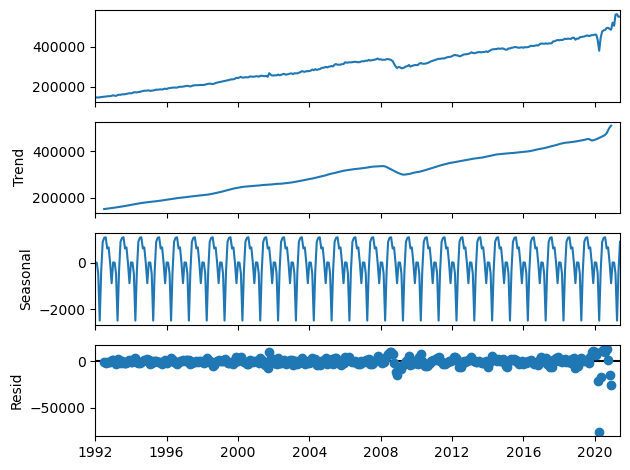

In [207]:
result=seasonal_decompose(df_final,model='additive', period=12)
result.plot()
plt.show()

There is a seasonal trend! Those residuals towards the end though get a little all over the place.

The next part was annoying because auto_arima only runs on newer versions of python that anaconda - jupyter notebook didnt have. Stil need to fix this.

# Use the training set to build a predictive model for the monthly retail sales.
# Use the model to predict the monthly retail sales on the last year of data.

In [222]:
sarimax_model=SARIMAX(train_data['value'], order=(1,1,1), seasonal_order=(1,0,1,12))
sarimax_result=sarimax_model.fit()
sarimax_predict=sarimax_result.predict(start=len(train_data),end=len(df_final)-1)
print(model_fit.summary())

C:\Users\rwant\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\rwant\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\rwant\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                  342
Model:                 ARIMA(5, 1, 0)   Log Likelihood               -3442.629
Date:                Sun, 02 Nov 2025   AIC                           6897.257
Time:                        09:40:25   BIC                           6920.249
Sample:                    01-01-1992   HQIC                          6906.417
                         - 06-01-2020                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0087      0.009     -0.952      0.341      -0.027       0.009
ar.L2         -0.1073      0.015     -7.207      0.000      -0.136      -0.078
ar.L3         -0.0159      0.046     -0.343      0.7

# Report the RMSE of the model predictions on the test set.

In [221]:
rmse= np.sqrt(mean_squared_error(test_data, sarimax_predict))
print(f"RMSE: {rmse:.3f}")

RMSE: 52322.930


This RMSE seems high at first but when ou look at how quickly the trend increased we ended at above $500,000 monthly revenue this is better. I need to work on updating my python or ancaconda with the newer version that support pmdarima so it can iterate through and figute out the best order, seasonal_order combo.